In [37]:
"""""
This script is used for the results for the second research question.
Made by: Bram Bouman
date: 17/06/2026
"""

import pandas as pd 

#load in the data:
CR_db = pd.read_csv("processed_CR_db.csv")
patent_db = pd.read_csv("processed_patents.csv")

#drop first column, because it is extra and is not wanted: 
CR_db = CR_db.iloc[:, 1:]
patent_db = patent_db.iloc[:,1:]


#change european countries to europe, because they are all their own stakeholder
europe = ["Finland", "France", "Germany", "United Kingdom", "Sweden"]
CR_db["country"] = CR_db["country"].replace(europe, "Europe")
patent_db["country"] = patent_db["country"].replace(europe, "Europe")

C:\Users\Bram\AppData\Local\Temp\ipykernel_81772\768409098.py:10: DtypeWarning: Columns (0: abstract, 1: secretary_remarks, 2: ainumber, 3: ainame, 4: revisionof, 5: revisedto, 6: release, 7: crspec, 8: crspecversion, 9: workitem, 10: crnumber, 11: uicc_affected, 12: me_affected, 13: ran_affected, 14: cn_affected, 15: clauses_affected, 16: crsinpack) have mixed types. Specify dtype option on import or set low_memory=False.
  CR_db = pd.read_csv("processed_CR_db.csv")


In [38]:
companies = [
    "huawei", "ericsson", "hisilicon", "nokia", "zte", "qualcomm",
    "samsung", "catt", "intel", "ntt docomo", "china mobile",
    "lg", "vivo", "china telecom",
    "orange", "lenovo", "apple", "rohde schwarz", "oppo",
    "nec", "att", "interdigital", "deutsche telekom",
    "vodafone", "xiaomi", "motorola", "verizon",
    "keysight", "tmobile", "att",
    "kddi", "cisco", "sharp", "wilus"
]

## define effective monetization score ##
def Eff_monetization(company):
    CR_db_company = CR_db[CR_db["source"] == f"{company}"]
    patent_db_company = patent_db[patent_db["company"] == f"{company}"]

    country = CR_db_company["country"].unique()[0]

    standards_CR = CR_db_company["crspec"].unique()
    standards_CR = [str(x) for x in standards_CR]
    
    ## get all standards from the patents db ##
    import ast
    standards_patent = [
        item
        for x in patent_db_company["standards"]
        for item in (
            ast.literal_eval(x) if isinstance(x, str) and x.startswith('[')
            else ([x] if isinstance(x, str) else x)
        )]
    standards_patent = list(set(standards_patent))
    import re
    standards_CR = [x for x in standards_CR if re.fullmatch(r"\d{2}\.\d{3}", x)]
    standards_patent = [x for x in standards_patent if re.fullmatch(r"\d{2}\.\d{3}", x)]

    compensating = list(set(standards_CR).symmetric_difference(set(standards_patent)))
    S_cr = len(standards_CR)
    S_patent = len(standards_patent)

    if (S_cr == 0):
        return "No Change request standards", compensating, country
    if (S_patent == 0): 
        return "No patent standards", compensating, country
    
    M_eff = S_patent/S_cr
    return M_eff, compensating, country

## define change request score ##
def change_request_score(company):
    CR_db_company = CR_db[CR_db["source"] == f"{company}"]
    CR_db_company = CR_db_company.dropna(subset = ["crcategory"])

    N_cr = len(CR_db_company["crcategory"])

    total_types = (0.1*(CR_db_company["crcategory"] == "A").sum() + 1*(CR_db_company["crcategory"] == "B").sum() 
                   + 0.8*(CR_db_company["crcategory"] == "C").sum()
                   + 0.2*(CR_db_company["crcategory"] == "D").sum()
                   + 0.2*(CR_db_company["crcategory"] == "F").sum())
    CR_score = total_types / N_cr
    return CR_score


## producing the answer ##
answer = pd.DataFrame(columns = ["company", "M_eff", "compensating standards", "CR score", "CR amount", "country"])
for company in companies:
    M_eff, compensating,country = Eff_monetization(f"{company}")
    CR_score = change_request_score(company)
    CR_amount = (CR_db["source"] == company).sum()
    temp_answer = [company,M_eff, compensating, CR_score, CR_amount, country]
    answer.loc[len(answer)] = temp_answer
print(answer)

             company                M_eff  \
0             huawei             0.289827   
1           ericsson             0.203834   
2          hisilicon  No patent standards   
3              nokia             0.421316   
4                zte             0.489199   
5           qualcomm             0.393112   
6            samsung             0.515193   
7               catt                 0.25   
8              intel             0.258348   
9         ntt docomo             0.435443   
10      china mobile             0.286213   
11                lg             0.444126   
12              vivo             0.151515   
13     china telecom  No patent standards   
14            orange             0.468487   
15            lenovo             0.641379   
16             apple             0.804878   
17     rohde schwarz  No patent standards   
18              oppo             0.548673   
19               nec             0.974453   
20               att             0.290698   
21      in

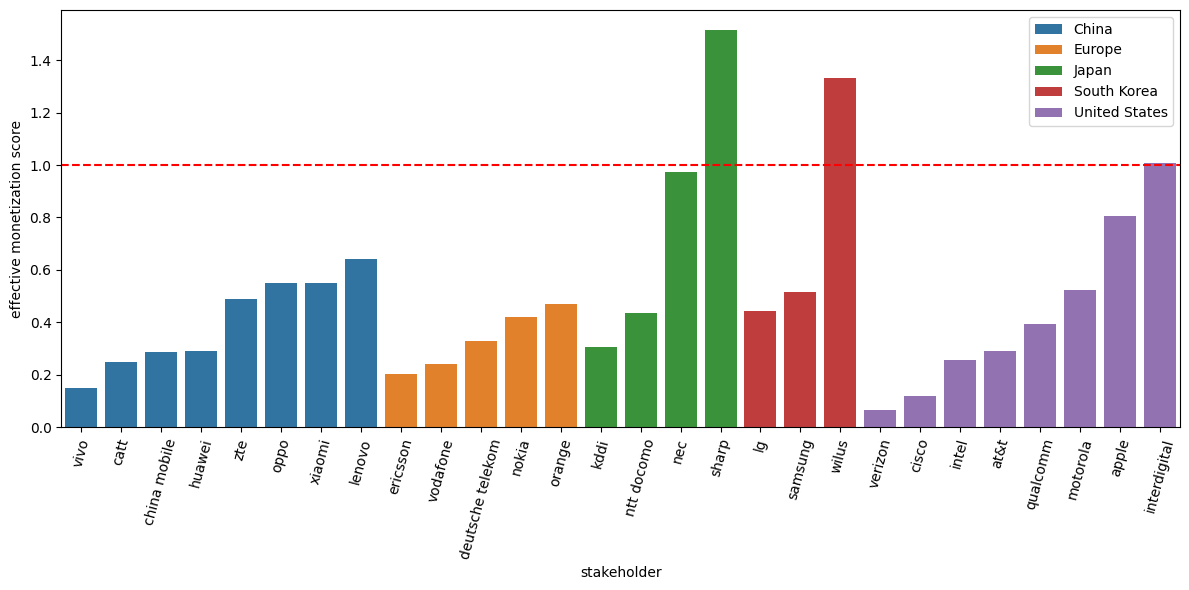

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

# example dataframe
# df columns: value, country, label
# label = x-axis categories
# value = bar height

answer["M_eff"] = answer["M_eff"].replace("No patent standards", 0)
answer = answer[answer["M_eff"] != 0]
answer["company"] = answer["company"].replace("att", "at&t")
answer = answer.sort_values(["country", "M_eff"])
plt.figure(figsize=(12,6))

sns.barplot(
    data=answer,
    x="company",
    y="M_eff",
    hue="country",
)
plt.axhline(1, color='red', linestyle='--')  

plt.xticks(rotation=75)
plt.xlabel("stakeholder")
plt.ylabel("effective monetization score")
plt.legend()
plt.tight_layout()
plt.show()

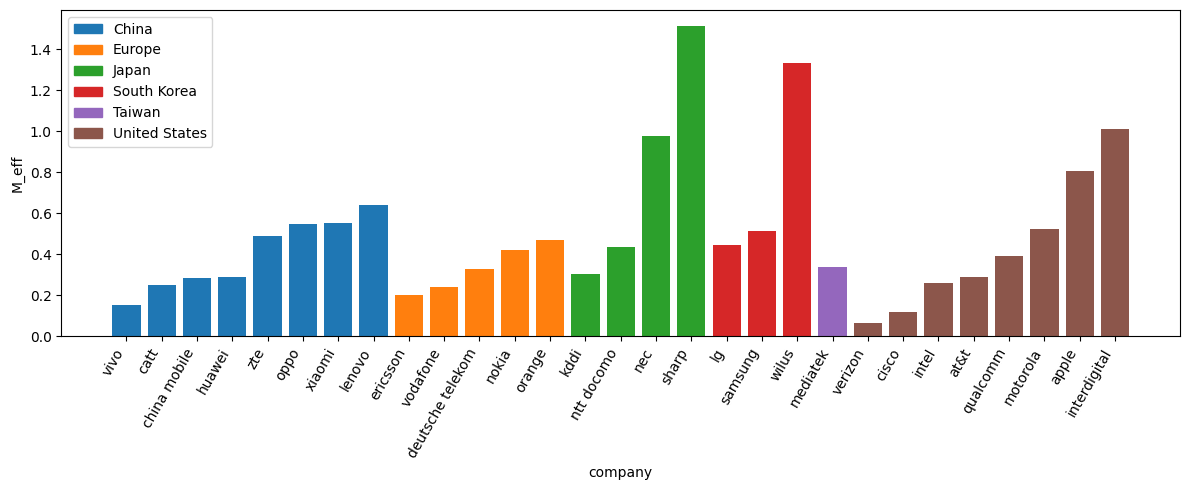

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# keep original order (VERY important)
df_plot = answer.copy()

# ensure consistent order on x-axis
order = df_plot["company"].tolist()

# map colors by country
palette = {
    "China": "#1f77b4",
    "Europe": "#ff7f0e",
    "Japan": "#2ca02c",
    "South Korea": "#d62728",
    "Taiwan": "#9467bd",
    "United States": "#8c564b"
}

colors = df_plot["country"].map(palette)

plt.figure(figsize=(12,5))

plt.bar(df_plot["company"], df_plot["M_eff"], color=colors)


legend_patches = [
    mpatches.Patch(color=color, label=country)
    for country, color in palette.items()
]
plt.legend(handles=legend_patches)

plt.xticks(rotation=60, ha="right")
plt.xlabel("company")
plt.ylabel("M_eff")

plt.tight_layout()
plt.show()

Correlation: -0.13816406525032288
P-value: 0.4747652236249948
Intercept: 0.46677191876987806
Slope: -2.740583691226517e-07
R-squared:  0.01908930892649552


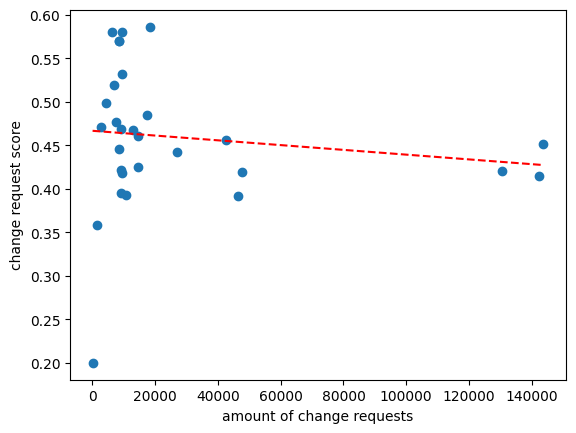

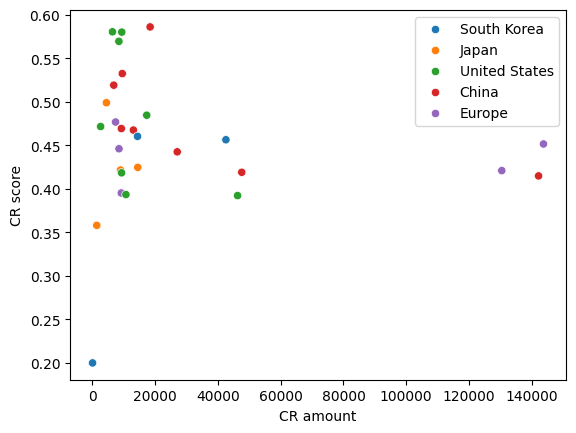

In [45]:
answer = answer.sort_values(by = "CR amount", ascending = True)

from scipy.stats import pearsonr
r, p_value = pearsonr(answer["CR amount"], answer["CR score"])
print("Correlation:", r)
print("P-value:", p_value)

import matplotlib.pyplot as plt
plt.scatter(answer["CR amount"], answer["CR score"])
plt.xlabel("amount of change requests")
plt.ylabel("change request score")


from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array(answer["CR amount"]).reshape(-1, 1)
y = np.array(answer["CR score"])

model = LinearRegression()
model.fit(X, y)
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

# predictions for regression line
y_pred = model.predict(X)

# plot regression line
plt.plot(X, y_pred, color="red", label="Regression line", linestyle = "--")

r2 = model.score(X, y)
print("R-squared: ",r2)

import seaborn as sns
plt.figure()
sns.scatterplot(data=answer, x="CR amount", y="CR score", hue="country")
plt.legend(title="")
plt.show()


Correlation: 0.8028524780417253
P-value: 9.39079142437866e-08
Intercept: 53.356741273219114
Slope: 0.27960423301904147
R-squared:  0.6445721014977386


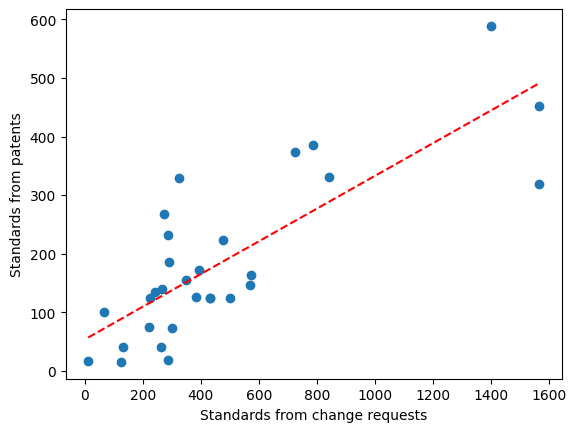

In [2]:
def get_Scr_Spatent(company):
    CR_db_company = CR_db[CR_db["source"] == f"{company}"]
    patent_db_company = patent_db[patent_db["company"] == f"{company}"]

    standards_CR = CR_db_company["crspec"].unique()
    standards_CR = [str(x) for x in standards_CR]
    
    ## get all standards from the patents db ##
    import ast
    standards_patent = [
        item
        for x in patent_db_company["standards"]
        for item in (
            ast.literal_eval(x) if isinstance(x, str) and x.startswith('[')
            else ([x] if isinstance(x, str) else x)
        )]
    standards_patent = list(set(standards_patent))
    import re
    standards_CR = [x for x in standards_CR if re.fullmatch(r"\d{2}\.\d{3}", x)]
    standards_patent = [x for x in standards_patent if re.fullmatch(r"\d{2}\.\d{3}", x)]

    S_cr = len(standards_CR)
    S_patent = len(standards_patent)
    return S_cr, S_patent

data = pd.DataFrame(columns = ["S_cr", "S_patent"])
companies = [
    "huawei", "ericsson", "hisilicon", "nokia", "zte", "qualcomm",
    "samsung", "catt", "intel", "ntt docomo", "china mobile",
    "lg", "mediatek", "vivo", "china telecom",
    "orange", "lenovo", "apple", "rohde schwarz", "oppo",
    "nec", "att", "interdigital", "deutsche telekom",
    "vodafone", "xiaomi", "motorola", "verizon",
    "keysight", "tmobile", "att",
    "kddi", "cisco", "sharp", "wilus"
]

for company in companies:
    S_cr, S_patent = get_Scr_Spatent(company)
    data.loc[len(data)] = [S_cr,S_patent]

data = data[data["S_cr"] != 0]
data = data[data["S_patent"] != 0]

from scipy.stats import pearsonr
r, p_value = pearsonr(data["S_cr"], data["S_patent"])
print("Correlation:", r)
print("P-value:", p_value)

import matplotlib.pyplot as plt
plt.scatter(data["S_cr"], data["S_patent"])
plt.xlabel("Standards from change requests")
plt.ylabel("Standards from patents")

data = data.sort_values(by="S_cr", ascending=True)

from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array(data["S_cr"]).reshape(-1, 1)
y = np.array(data["S_patent"])

model = LinearRegression()
model.fit(X, y)
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

# predictions for regression line
y_pred = model.predict(X)

# plot regression line
plt.plot(X, y_pred, color="red", label="Regression line", linestyle = "--")

r2 = model.score(X, y)
print("R-squared: ",r2)